# Fine-tuning a Pre-trained Convolutional Neural Network for the Grainset Image Dataset

For our Neural Network, we will use a pre-trained model in order to perform classification tasks. We chose a CNN model, specifically EfficientNetV2-small, in order to utilize its convolutional blocks that can extract features from images and is still a relatively small model.

In [1]:
import matplotlib.pyplot as plt
from neural_network_utils import (
    GrainDataModule,
    IDX_TO_CLASS,
    LightningModel,
    plot_loss_and_acc,
)
import lightning as L
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%load_ext watermark
%watermark -p torch,lightning,torchvision,torchmetrics


torch       : 2.10.0
lightning   : 2.6.1
torchvision : 0.25.0
torchmetrics: 1.8.2



## Preparing the Pre-Trained Model

We will use the EfficientNetV2-small model pretrained using the Imagenet1K-v1 dataset in order to leverage the feature extraction ability that the model has acquired when training the model on the thousand classes of images on the dataset.

In [3]:
efficientnet_v2_s = torch.hub.load(
    "pytorch/vision:v0.25.0", "efficientnet_v2_s", weights="IMAGENET1K_V1"
)

Using cache found in /home/xandreiathome/.cache/torch/hub/pytorch_vision_v0.25.0


In [4]:
efficientnet_v2_s

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [5]:
len(list(efficientnet_v2_s.features))

8

For this project, we will not train the whole model as it will be computationally expensive. Instead we will train the last 3 convolutional blocks in order to for those blocks to adapt to our dataset. This will also leverage the capability of the earlier convolutional blocks of EfficientNet, to extract the generic features of an image.

Reference: https://www.identifyshell.org/blog-fine-tuning-efficientnetv2-models.php

In [6]:
for param in efficientnet_v2_s.features[:5].parameters():
    param.requires_grad = False

for param in efficientnet_v2_s.features[5:].parameters():
    param.requires_grad = True

efficientnet_v2_s.classifier[1] = torch.nn.Linear(1280, 14)

In [7]:
efficientnet_v2_s

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [8]:
from torchvision.models import EfficientNet_V2_S_Weights

weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()
preprocess_transform

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

We will also add some augmentations for the training set. A weighted sampler for the training set is also implemented in the DataModule in order to mitigate the class imbalance in the dataset.

In [9]:
import torchvision.transforms as T

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
train_transform = T.Compose(
    [
        T.RandomResizedCrop(384),
        T.RandomHorizontalFlip(),
        T.RandomRotation(20),
        T.ColorJitter(0.2, 0.2, 0.2),
        T.ToTensor(),
        T.Normalize(mean, std),
        T.RandomErasing(p=0.25),
    ]
)

## Preparing the Dataset and Loaders
A quick check in order to make sure that the dataloader is able to load the images properly

In [10]:
data_module = GrainDataModule(
    data_dir="dataset/images",
    batch_size=64,
    train_transform=train_transform,
    val_transform=preprocess_transform,
    test_transform=preprocess_transform,
)

In [11]:
data_module.setup()

In [12]:
print("Train size:", len(data_module.train_dataset))
print("Val size:", len(data_module.val_dataset))
print("Test size:", len(data_module.test_dataset))

Train size: 34395
Val size: 6067
Test size: 4500


We used a weighted sampling in order to address the class imbalance in the dataset. Let's check if it working and not sampling the majority classes which are rice_0_NOR and maize_0_nor.

torch.Size([64, 3, 384, 384])
torch.Size([64])


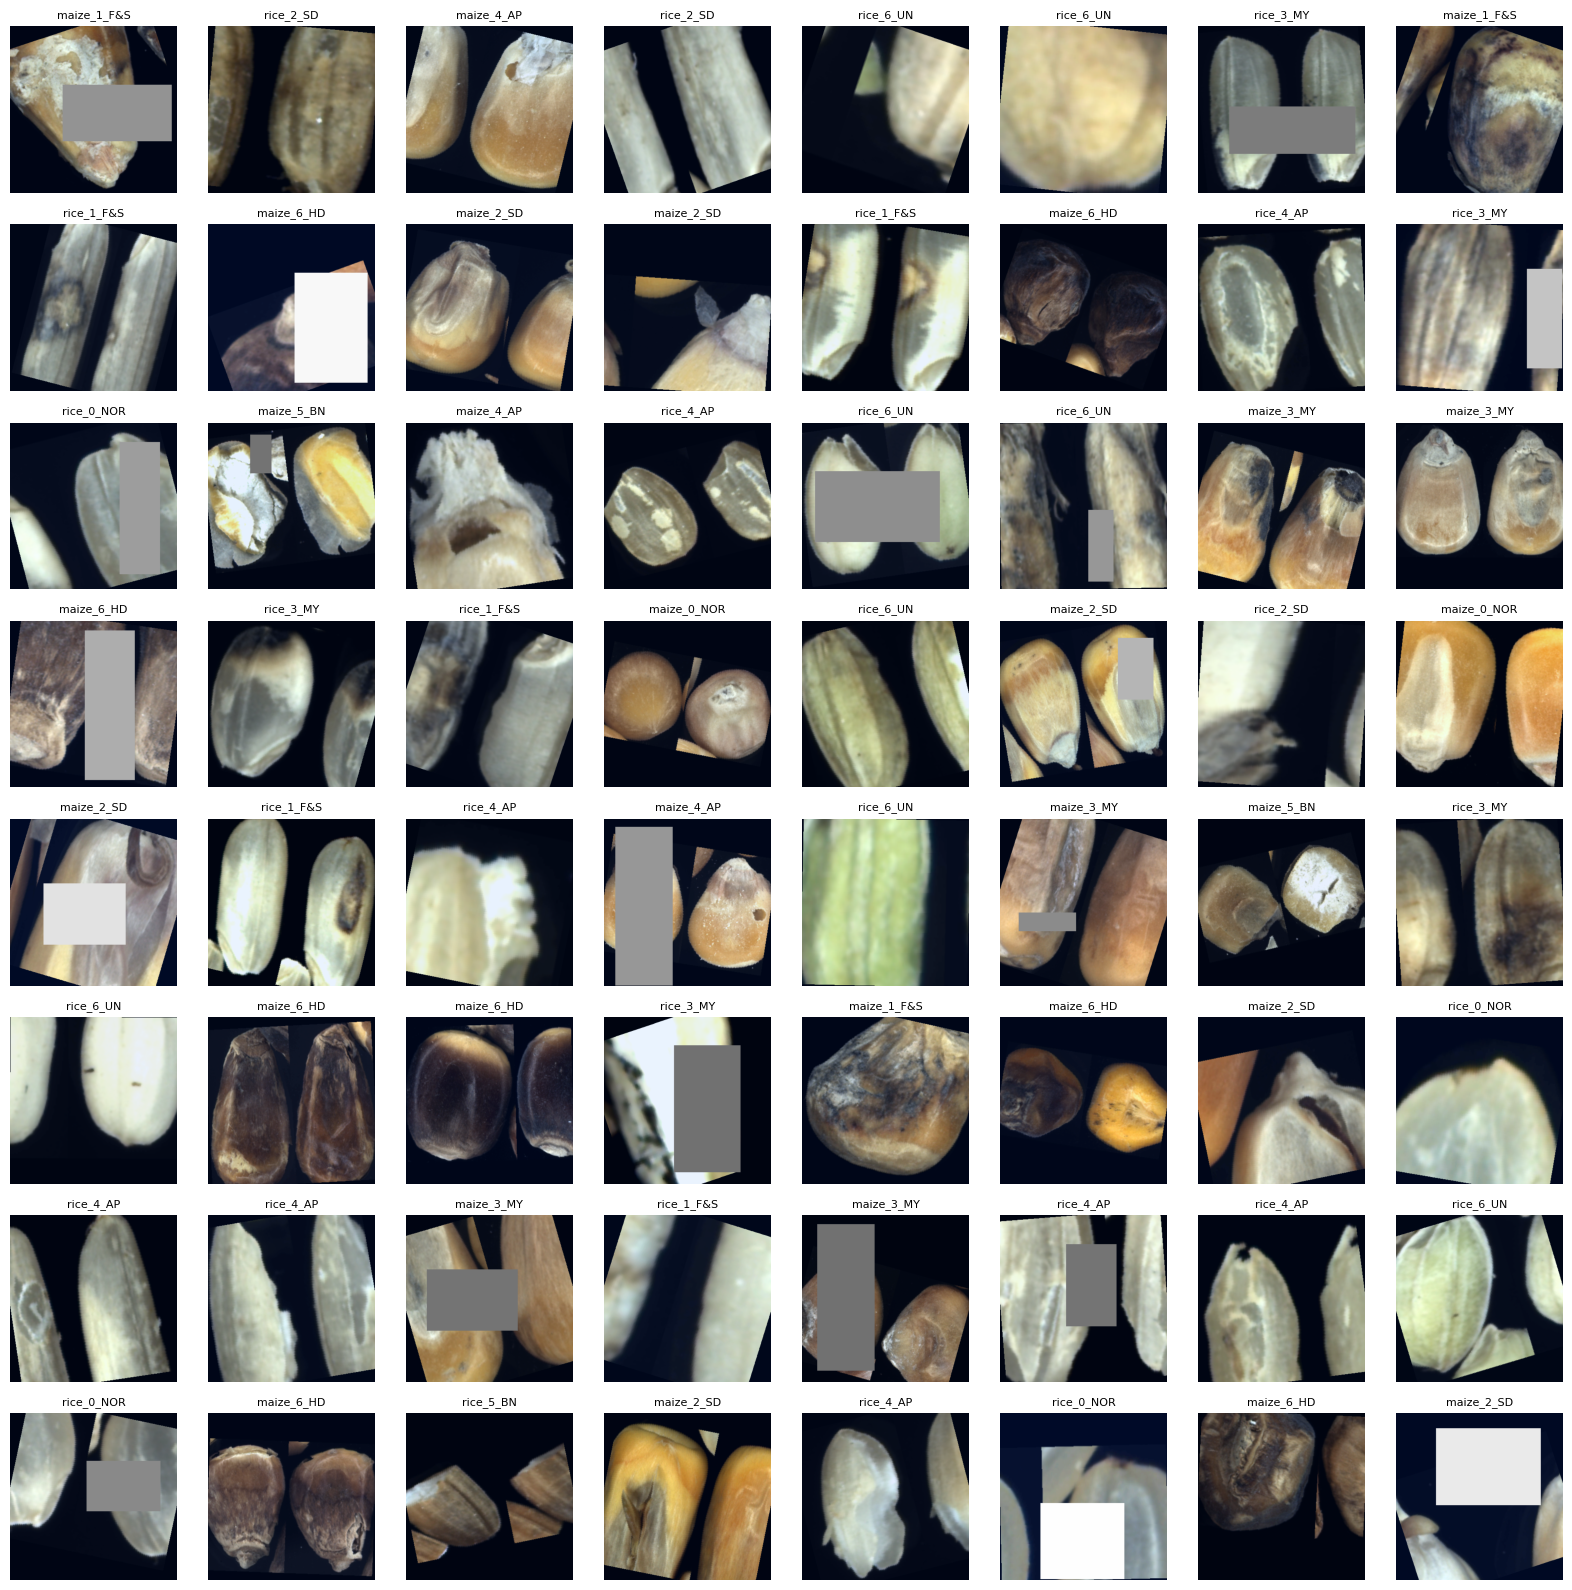

Displayed 64 images from the batch
CLASS DISTRIBUTION IN BATCH
rice_6_UN: 8 images (12.5%)
maize_6_HD: 8 images (12.5%)
rice_4_AP: 8 images (12.5%)
maize_2_SD: 7 images (10.9%)
rice_3_MY: 5 images (7.8%)
rice_1_F&S: 5 images (7.8%)
maize_3_MY: 5 images (7.8%)
rice_0_NOR: 4 images (6.2%)
maize_1_F&S: 3 images (4.7%)
rice_2_SD: 3 images (4.7%)
maize_4_AP: 3 images (4.7%)
maize_5_BN: 2 images (3.1%)
maize_0_NOR: 2 images (3.1%)
rice_5_BN: 1 images (1.6%)


In [13]:
train_loader = data_module.train_dataloader()

batch_images, batch_labels = next(iter(train_loader))

print(batch_images.shape)
print(batch_labels.shape)

# Display all images in the batch in a grid
n_images = batch_images.shape[0]
n_cols = 8
n_rows = (n_images + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2 * n_rows))
axes = axes.flatten()

for idx in range(n_images):
    img = batch_images[idx].permute(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-5)

    axes[idx].imshow(img.cpu().numpy())
    class_label = IDX_TO_CLASS[batch_labels[idx].item()]
    axes[idx].set_title(class_label, fontsize=8)
    axes[idx].axis("off")

for idx in range(n_images, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

print(f"Displayed {n_images} images from the batch")

# Calculate class distribution
print("CLASS DISTRIBUTION IN BATCH")

class_counts = {}
for label_idx in batch_labels:
    class_name = IDX_TO_CLASS[label_idx.item()]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

# Sort by counts descending
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

for class_name, count in sorted_classes:
    percentage = (count / n_images) * 100
    print(f"{class_name}: {count} images ({percentage:.1f}%)")

# Preparing Hyperparameters for the Model

We will use the utility tuners that come with Lightning in order to find a good baseline for the learning rate and batch sizes.

In [14]:
L.seed_everything(67)

num_epochs = 1
num_steps = num_epochs * len(data_module.train_dataloader())
lightning_model = LightningModel(
    model=efficientnet_v2_s,
    learning_rate=0.001,
    num_classes=14,
    cosine_t_max=num_steps,
)

debug_trainer = L.Trainer(
    accelerator="gpu",
    devices="auto",
    logger=None,
    deterministic=True,
)

Seed set to 67
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [15]:
from lightning.pytorch.tuner import Tuner

In [16]:
tuner = Tuner(debug_trainer)

new_batch_size = tuner.scale_batch_size(
    model=lightning_model, datamodule=data_module, mode="power"
)

print(new_batch_size)

/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.
/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree

8


In [17]:
data_module.batch_size = 8

In [ ]:
lr_finder = tuner.lr_find(lightning_model, datamodule=data_module)

# Plot
fig = lr_finder.plot(suggest=True)
fig.show()

# Get suggested LR
new_lr = lr_finder.suggestion()
print(new_lr)

## Traing the Model

We will use CosineAnnealing learning rate scheduler alongside Adam optimizer in order to improve the loss convergence of the model

In [18]:
from lightning.pytorch.callbacks import ModelCheckpoint

callbacks = [
    ModelCheckpoint(save_top_k=1, mode="max", monitor="val_macro_f1", save_last=True)
]

In [19]:
lightning_model.learning_rate = new_lr

NameError: name 'new_lr' is not defined

In [20]:
trainer = L.Trainer(
    max_epochs=2,
    accelerator="gpu",
    devices="auto",
    logger=CSVLogger(save_dir="logs/", name="tuned-efficientnet"),
    deterministic=True,
    callbacks=callbacks,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [21]:
trainer.fit(model=lightning_model, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                     ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model                    │ EfficientNet        │ 20.2 M │ train │     0 │
│ 1  │ train_acc                │ MulticlassAccuracy  │      0 │ train │     0 │
│ 2  │ val_acc                  │ MulticlassAccuracy  │      0 │ train │     0 │
│ 3  │ val_macro_f1             │ MulticlassF1Score   │      0 │ train │     0 │
│ 4  │ test_acc                 │ MulticlassAccuracy  │      0 │ train │     0 │
│ 5  │ test_macro_precision     │ MulticlassPrecision │      0 │ train │     0 │
│ 6  │ test_macro_recall        │ MulticlassRecall    │      0 │ train │     0 │
│ 7  │ test_macro_f1            │ MulticlassF1Score   │      0 │ train │     0 │
│ 8  │ test_precision_per_class │ MulticlassPrecision │      0 │ train │     0 │
│ 9  │ test_recall_per_class    │ MulticlassRecall    │      0 │ train │     0 │
│ 10 │ test_f1_per_class        │ MulticlassF1Score   │      0 │ train │     0 │
└────┴──────────────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 18.4 M                                                                                           
Non-trainable params: 1.8 M                                                                                        
Total params: 20.2 M                                                                                               
Total estimated model params size (MB): 80                                                                         
Modules in train mode: 724                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
trainer.test(model=lightning_model, datamodule=data_module)

In [ ]:
plot_loss_and_acc(log_dir=trainer.logger.log_dir, loss_ylim=(0.0, 2.0))